# Results Analysis

Loads `results/tables/metrics.csv` and produces:
1. Aggregated metrics tables (mean ± std over seeds for AE/VAE)
2. Per-market method comparison table (best config per method)
3. Embedding-dimension ablation table
4. Method comparison bar plots
5. Performance vs embedding-dim line plots
6. Cross-market comparison table

All plots are saved to `results/plots/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT   = Path(".").resolve()
METRICS_CSV = REPO_ROOT / "results" / "tables" / "metrics.csv"
PLOTS_DIR   = REPO_ROOT / "results" / "plots"
TABLES_DIR  = REPO_ROOT / "results" / "tables"
PLOTS_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

MARKETS = ["OMXS", "SPX"]
DIMS    = [8, 16, 32]

METRICS = ["test_accuracy", "test_f1", "test_balanced_accuracy"]
METRIC_LABELS = {
    "test_accuracy":          "Accuracy",
    "test_f1":                "F1",
    "test_balanced_accuracy": "Bal. Accuracy",
}

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "font.size":         10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

## 1. Load & Parse `metrics.csv`

The CSV has no header and different column layouts per method — parse by routing on the method field.

In [2]:
rows_baseline, rows_pca, rows_ae, rows_vae = [], [], [], []

with open(METRICS_CSV) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        p = line.split(",")
        market, method = p[0], p[1]

        if method == "baseline_handcrafted":
            # cols: market, method, emb_dim(empty), n_features, threshold, best_C,
            #       val_acc, val_f1, val_bal_acc, test_acc, test_f1, test_bal_acc
            rows_baseline.append({
                "market": market,
                "test_accuracy":          float(p[9]),
                "test_f1":                float(p[10]),
                "test_balanced_accuracy": float(p[11]),
            })

        elif method == "pca":
            # cols: market, method, emb_dim, n_features, threshold, best_C,
            #       val_acc, val_f1, val_bal_acc, test_acc, test_f1, test_bal_acc
            rows_pca.append({
                "market":        market,
                "embedding_dim": int(p[2]),
                "test_accuracy":          float(p[9]),
                "test_f1":                float(p[10]),
                "test_balanced_accuracy": float(p[11]),
            })

        elif method == "ae_mlp":
            # cols: market, method, emb_dim, seed, n_features, threshold, best_C,
            #       val_acc, val_f1, val_bal_acc, test_acc, test_f1, test_bal_acc
            rows_ae.append({
                "market":        market,
                "embedding_dim": int(p[2]),
                "seed":          int(p[3]),
                "test_accuracy":          float(p[10]),
                "test_f1":                float(p[11]),
                "test_balanced_accuracy": float(p[12]),
            })

        elif method == "vae":
            # cols: market, method, emb_dim, n_features, seed, beta, threshold, best_C,
            #       val_acc, val_f1, val_bal_acc, test_acc, test_f1, test_bal_acc, ...
            rows_vae.append({
                "market":        market,
                "embedding_dim": int(p[2]),
                "seed":          int(p[4]),
                "test_accuracy":          float(p[11]),
                "test_f1":                float(p[12]),
                "test_balanced_accuracy": float(p[13]),
            })
        # vae_meanstd rows are skipped — we recompute aggregates ourselves

df_baseline = pd.DataFrame(rows_baseline)
df_pca      = pd.DataFrame(rows_pca)
df_ae       = pd.DataFrame(rows_ae)
df_vae      = pd.DataFrame(rows_vae)

print(f"Baseline : {len(df_baseline)} rows")
print(f"PCA      : {len(df_pca)} rows")
print(f"AE       : {len(df_ae)} rows")
print(f"VAE      : {len(df_vae)} rows")

Baseline : 2 rows
PCA      : 6 rows
AE       : 18 rows
VAE      : 18 rows


## 2. Aggregate AE / VAE Over Seeds

In [3]:
GROUP = ["market", "embedding_dim"]

def aggregate_seeds(df):
    agg = df.groupby(GROUP)[METRICS].agg(["mean", "std"])
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    return agg.reset_index()

ae_agg  = aggregate_seeds(df_ae)
vae_agg = aggregate_seeds(df_vae)

print("=== AE aggregated ===")
display(ae_agg)
print("\n=== VAE aggregated ===")
display(vae_agg)

=== AE aggregated ===


,market,embedding_dim,test_accuracy_mean,test_accuracy_std,test_f1_mean,test_f1_std,test_balanced_accuracy_mean,test_balanced_accuracy_std
0,OMXS,8,0.832429,0.013552,0.717231,0.023788,0.783811,0.015954
1,OMXS,16,0.871551,0.002073,0.784191,0.003691,0.828773,0.002613
2,OMXS,32,0.888738,0.001795,0.816418,0.002063,0.852192,0.001790
3,SPX,8,0.867441,0.005566,0.885632,0.005001,0.868475,0.005426
4,SPX,16,0.874740,0.008416,0.891554,0.007342,0.876840,0.008668
5,SPX,32,0.885632,0.012194,0.901233,0.010566,0.887564,0.012560



=== VAE aggregated ===


,market,embedding_dim,test_accuracy_mean,test_accuracy_std,test_f1_mean,test_f1_std,test_balanced_accuracy_mean,test_balanced_accuracy_std
0,OMXS,8,0.823157,0.004618,0.697571,0.009158,0.770403,0.006109
1,OMXS,16,0.844867,0.010430,0.742231,0.013975,0.801121,0.008699
2,OMXS,32,0.907960,0.002073,0.849961,0.004446,0.876627,0.003956
3,SPX,8,0.790972,0.015230,0.821816,0.011585,0.786486,0.017811
4,SPX,16,0.858571,0.005057,0.878464,0.003769,0.858390,0.007021
5,SPX,32,0.895626,0.009709,0.909921,0.008484,0.897775,0.009814


## 3. Summary Tables

In [4]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def fmt(val, std=None):
    """Format a value, optionally with ± std."""
    if std is not None and not np.isnan(std):
        return f"{val:.4f} \u00b1{std:.4f}"
    return f"{val:.4f}"

def best_pca(market, sort_metric="test_balanced_accuracy"):
    sub = df_pca[df_pca["market"] == market]
    return sub.loc[sub[sort_metric].idxmax()]

def best_agg(agg_df, market, sort_metric="test_balanced_accuracy"):
    sub = agg_df[agg_df["market"] == market]
    return sub.loc[sub[f"{sort_metric}_mean"].idxmax()]


# ── Per-market method comparison (best dim per method) ────────────────────────

rows = []
for market in MARKETS:
    b = df_baseline[df_baseline["market"] == market].iloc[0]
    p = best_pca(market)
    a = best_agg(ae_agg,  market)
    v = best_agg(vae_agg, market)

    rows += [
        {"Market": market, "Method": "Baseline", "Dim": "—",
         "Accuracy":  fmt(b["test_accuracy"]),
         "F1":        fmt(b["test_f1"]),
         "Bal. Acc.": fmt(b["test_balanced_accuracy"])},

        {"Market": market, "Method": "PCA", "Dim": int(p["embedding_dim"]),
         "Accuracy":  fmt(p["test_accuracy"]),
         "F1":        fmt(p["test_f1"]),
         "Bal. Acc.": fmt(p["test_balanced_accuracy"])},

        {"Market": market, "Method": "AE", "Dim": int(a["embedding_dim"]),
         "Accuracy":  fmt(a["test_accuracy_mean"],          a["test_accuracy_std"]),
         "F1":        fmt(a["test_f1_mean"],                a["test_f1_std"]),
         "Bal. Acc.": fmt(a["test_balanced_accuracy_mean"], a["test_balanced_accuracy_std"])},

        {"Market": market, "Method": "VAE", "Dim": int(v["embedding_dim"]),
         "Accuracy":  fmt(v["test_accuracy_mean"],          v["test_accuracy_std"]),
         "F1":        fmt(v["test_f1_mean"],                v["test_f1_std"]),
         "Bal. Acc.": fmt(v["test_balanced_accuracy_mean"], v["test_balanced_accuracy_std"])},
    ]

summary_df = pd.DataFrame(rows)
display(summary_df)

,Market,Method,Dim,Accuracy,F1,Bal. Acc.
0,OMXS,Baseline,—,0.8182,0.6876,0.7638
1,OMXS,PCA,16,0.9138,0.8584,0.8814
2,OMXS,AE,32,0.8887 ±0.0018,0.8164 ±0.0021,0.8522 ±0.0018
3,OMXS,VAE,32,0.9080 ±0.0021,0.8500 ±0.0044,0.8766 ±0.0040
4,SPX,Baseline,—,0.7979,0.8233,0.7994
5,SPX,PCA,32,0.9459,0.9535,0.9491
6,SPX,AE,32,0.8856 ±0.0122,0.9012 ±0.0106,0.8876 ±0.0126
7,SPX,VAE,32,0.8956 ±0.0097,0.9099 ±0.0085,0.8978 ±0.0098


In [5]:
# LaTeX export — method comparison
latex_summary = summary_df.to_latex(
    index=False,
    escape=False,
    caption="Test-set performance of all methods (best embedding dimension; AE/VAE: mean $\\pm$ std over three seeds).",
    label="tab:method_comparison",
    column_format="llcrrr",
)
print(latex_summary)

(TABLES_DIR / "method_comparison.tex").write_text(latex_summary)
summary_df.to_csv(TABLES_DIR / "method_comparison.csv", index=False)
print("Saved method_comparison.tex / .csv")

\begin{table}
\caption{Test-set performance of all methods (best embedding dimension; AE/VAE: mean $\pm$ std over three seeds).}
\label{tab:method_comparison}
\begin{tabular}{llcrrr}
\toprule
Market & Method & Dim & Accuracy & F1 & Bal. Acc. \\
\midrule
OMXS & Baseline & — & 0.8182 & 0.6876 & 0.7638 \\
OMXS & PCA & 16 & 0.9138 & 0.8584 & 0.8814 \\
OMXS & AE & 32 & 0.8887 ±0.0018 & 0.8164 ±0.0021 & 0.8522 ±0.0018 \\
OMXS & VAE & 32 & 0.9080 ±0.0021 & 0.8500 ±0.0044 & 0.8766 ±0.0040 \\
SPX & Baseline & — & 0.7979 & 0.8233 & 0.7994 \\
SPX & PCA & 32 & 0.9459 & 0.9535 & 0.9491 \\
SPX & AE & 32 & 0.8856 ±0.0122 & 0.9012 ±0.0106 & 0.8876 ±0.0126 \\
SPX & VAE & 32 & 0.8956 ±0.0097 & 0.9099 ±0.0085 & 0.8978 ±0.0098 \\
\bottomrule
\end{tabular}
\end{table}

Saved method_comparison.tex / .csv


In [6]:
# ── Embedding-dimension ablation table ───────────────────────────────────────

dim_rows = []
for market in MARKETS:
    for dim in DIMS:
        # PCA
        sub = df_pca[(df_pca["market"] == market) & (df_pca["embedding_dim"] == dim)]
        if len(sub):
            r = sub.iloc[0]
            dim_rows.append({"Market": market, "Method": "PCA", "Dim": dim,
                             "Accuracy":  fmt(r["test_accuracy"]),
                             "F1":        fmt(r["test_f1"]),
                             "Bal. Acc.": fmt(r["test_balanced_accuracy"])})

        # AE
        sub = ae_agg[(ae_agg["market"] == market) & (ae_agg["embedding_dim"] == dim)]
        if len(sub):
            r = sub.iloc[0]
            dim_rows.append({"Market": market, "Method": "AE", "Dim": dim,
                             "Accuracy":  fmt(r["test_accuracy_mean"],          r["test_accuracy_std"]),
                             "F1":        fmt(r["test_f1_mean"],                r["test_f1_std"]),
                             "Bal. Acc.": fmt(r["test_balanced_accuracy_mean"], r["test_balanced_accuracy_std"])})

        # VAE
        sub = vae_agg[(vae_agg["market"] == market) & (vae_agg["embedding_dim"] == dim)]
        if len(sub):
            r = sub.iloc[0]
            dim_rows.append({"Market": market, "Method": "VAE", "Dim": dim,
                             "Accuracy":  fmt(r["test_accuracy_mean"],          r["test_accuracy_std"]),
                             "F1":        fmt(r["test_f1_mean"],                r["test_f1_std"]),
                             "Bal. Acc.": fmt(r["test_balanced_accuracy_mean"], r["test_balanced_accuracy_std"])})

dim_df = pd.DataFrame(dim_rows)
display(dim_df)

,Market,Method,Dim,Accuracy,F1,Bal. Acc.
0,OMXS,PCA,8,0.8962,0.8176,0.8467
1,OMXS,AE,8,0.8324 ±0.0136,0.7172 ±0.0238,0.7838 ±0.0160
2,OMXS,VAE,8,0.8232 ±0.0046,0.6976 ±0.0092,0.7704 ±0.0061
3,OMXS,PCA,16,0.9138,0.8584,0.8814
4,OMXS,AE,16,0.8716 ±0.0021,0.7842 ±0.0037,0.8288 ±0.0026
5,OMXS,VAE,16,0.8449 ±0.0104,0.7422 ±0.0140,0.8011 ±0.0087
6,OMXS,PCA,32,0.9172,0.8617,0.8814
7,OMXS,AE,32,0.8887 ±0.0018,0.8164 ±0.0021,0.8522 ±0.0018
8,OMXS,VAE,32,0.9080 ±0.0021,0.8500 ±0.0044,0.8766 ±0.0040
9,SPX,PCA,8,0.9239,0.9335,0.9297


In [7]:
# LaTeX export — dim ablation
latex_dim = dim_df.to_latex(
    index=False,
    escape=False,
    caption="Test-set performance as a function of embedding dimension (AE/VAE: mean $\\pm$ std over three seeds).",
    label="tab:dim_ablation",
    column_format="llcrrr",
)
print(latex_dim)

(TABLES_DIR / "dim_ablation.tex").write_text(latex_dim)
dim_df.to_csv(TABLES_DIR / "dim_ablation.csv", index=False)
print("Saved dim_ablation.tex / .csv")

\begin{table}
\caption{Test-set performance as a function of embedding dimension (AE/VAE: mean $\pm$ std over three seeds).}
\label{tab:dim_ablation}
\begin{tabular}{llcrrr}
\toprule
Market & Method & Dim & Accuracy & F1 & Bal. Acc. \\
\midrule
OMXS & PCA & 8 & 0.8962 & 0.8176 & 0.8467 \\
OMXS & AE & 8 & 0.8324 ±0.0136 & 0.7172 ±0.0238 & 0.7838 ±0.0160 \\
OMXS & VAE & 8 & 0.8232 ±0.0046 & 0.6976 ±0.0092 & 0.7704 ±0.0061 \\
OMXS & PCA & 16 & 0.9138 & 0.8584 & 0.8814 \\
OMXS & AE & 16 & 0.8716 ±0.0021 & 0.7842 ±0.0037 & 0.8288 ±0.0026 \\
OMXS & VAE & 16 & 0.8449 ±0.0104 & 0.7422 ±0.0140 & 0.8011 ±0.0087 \\
OMXS & PCA & 32 & 0.9172 & 0.8617 & 0.8814 \\
OMXS & AE & 32 & 0.8887 ±0.0018 & 0.8164 ±0.0021 & 0.8522 ±0.0018 \\
OMXS & VAE & 32 & 0.9080 ±0.0021 & 0.8500 ±0.0044 & 0.8766 ±0.0040 \\
SPX & PCA & 8 & 0.9239 & 0.9335 & 0.9297 \\
SPX & AE & 8 & 0.8674 ±0.0056 & 0.8856 ±0.0050 & 0.8685 ±0.0054 \\
SPX & VAE & 8 & 0.7910 ±0.0152 & 0.8218 ±0.0116 & 0.7865 ±0.0178 \\
SPX & PCA & 16 & 0.9424 

## 4. Core Plots

### 4a. Method Comparison Bar Chart

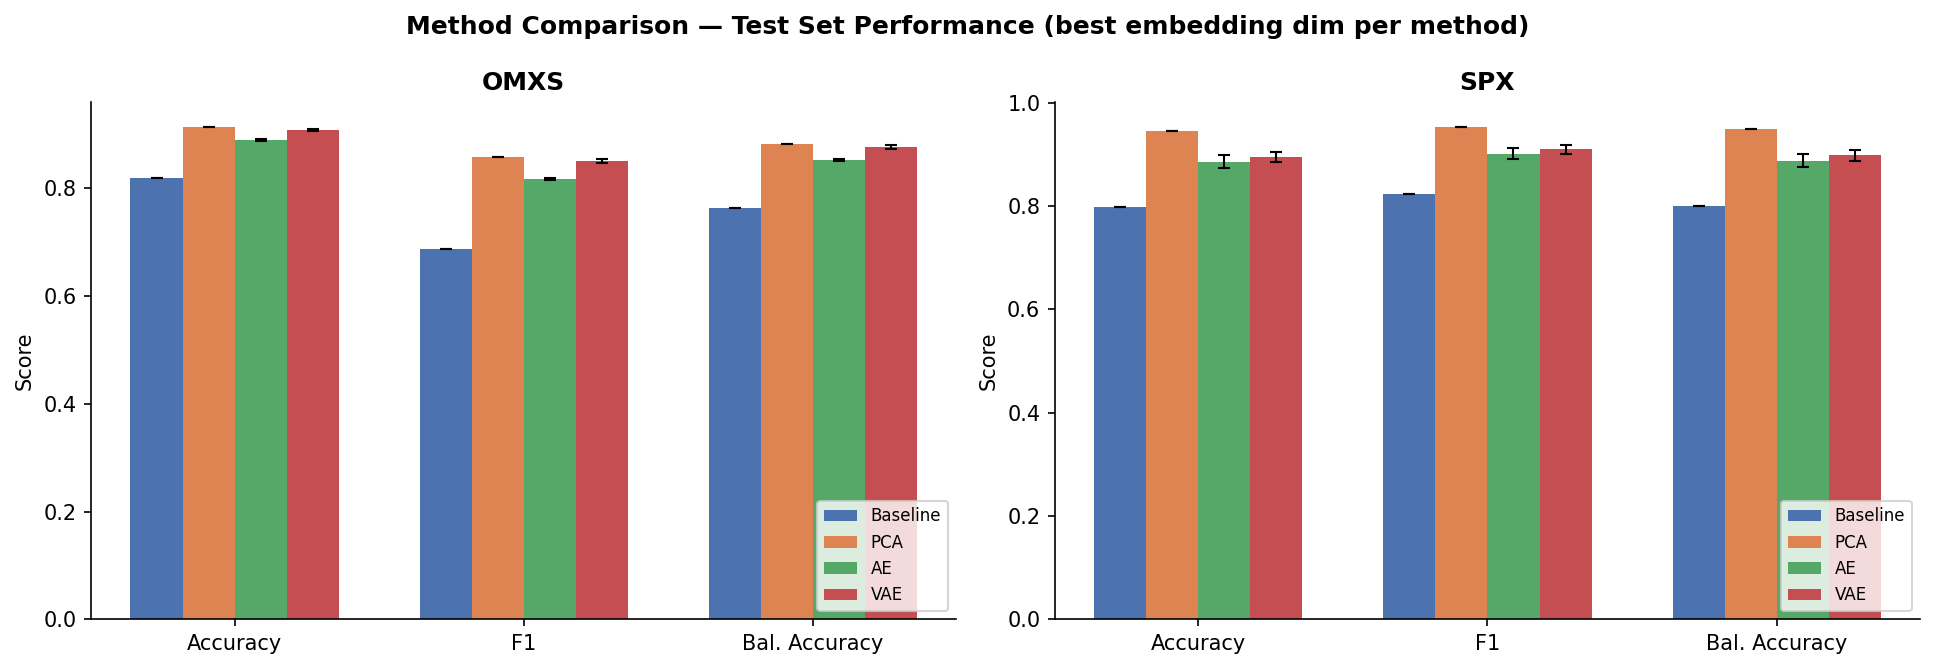

Saved method_comparison.pdf / .png


In [8]:
METHOD_ORDER  = ["Baseline", "PCA", "AE", "VAE"]
METHOD_COLORS = {"Baseline": "#4C72B0", "PCA": "#DD8452", "AE": "#55A868", "VAE": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, market in zip(axes, MARKETS):
    x      = np.arange(len(METRICS))
    width  = 0.18
    offset = np.linspace(-1.5 * width, 1.5 * width, len(METHOD_ORDER))

    b = df_baseline[df_baseline["market"] == market].iloc[0]
    p = best_pca(market)
    a = best_agg(ae_agg,  market)
    v = best_agg(vae_agg, market)

    data = {
        "Baseline": {"vals": [b[m]            for m in METRICS], "errs": [0]*3},
        "PCA":      {"vals": [p[m]            for m in METRICS], "errs": [0]*3},
        "AE":       {"vals": [a[f"{m}_mean"] for m in METRICS],
                     "errs": [a[f"{m}_std"]  for m in METRICS]},
        "VAE":      {"vals": [v[f"{m}_mean"] for m in METRICS],
                     "errs": [v[f"{m}_std"]  for m in METRICS]},
    }

    for i, method in enumerate(METHOD_ORDER):
        ax.bar(
            x + offset[i], data[method]["vals"], width,
            label=method,
            color=METHOD_COLORS[method],
            yerr=data[method]["errs"],
            capsize=3,
            error_kw={"linewidth": 1},
        )

    ax.set_title(market, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS])
    ax.set_ylabel("Score")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))

fig.suptitle("Method Comparison — Test Set Performance (best embedding dim per method)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "method_comparison.pdf", bbox_inches="tight")
plt.savefig(PLOTS_DIR / "method_comparison.png", bbox_inches="tight")
plt.show()
print("Saved method_comparison.pdf / .png")

### 4b. Performance vs Embedding Dimension

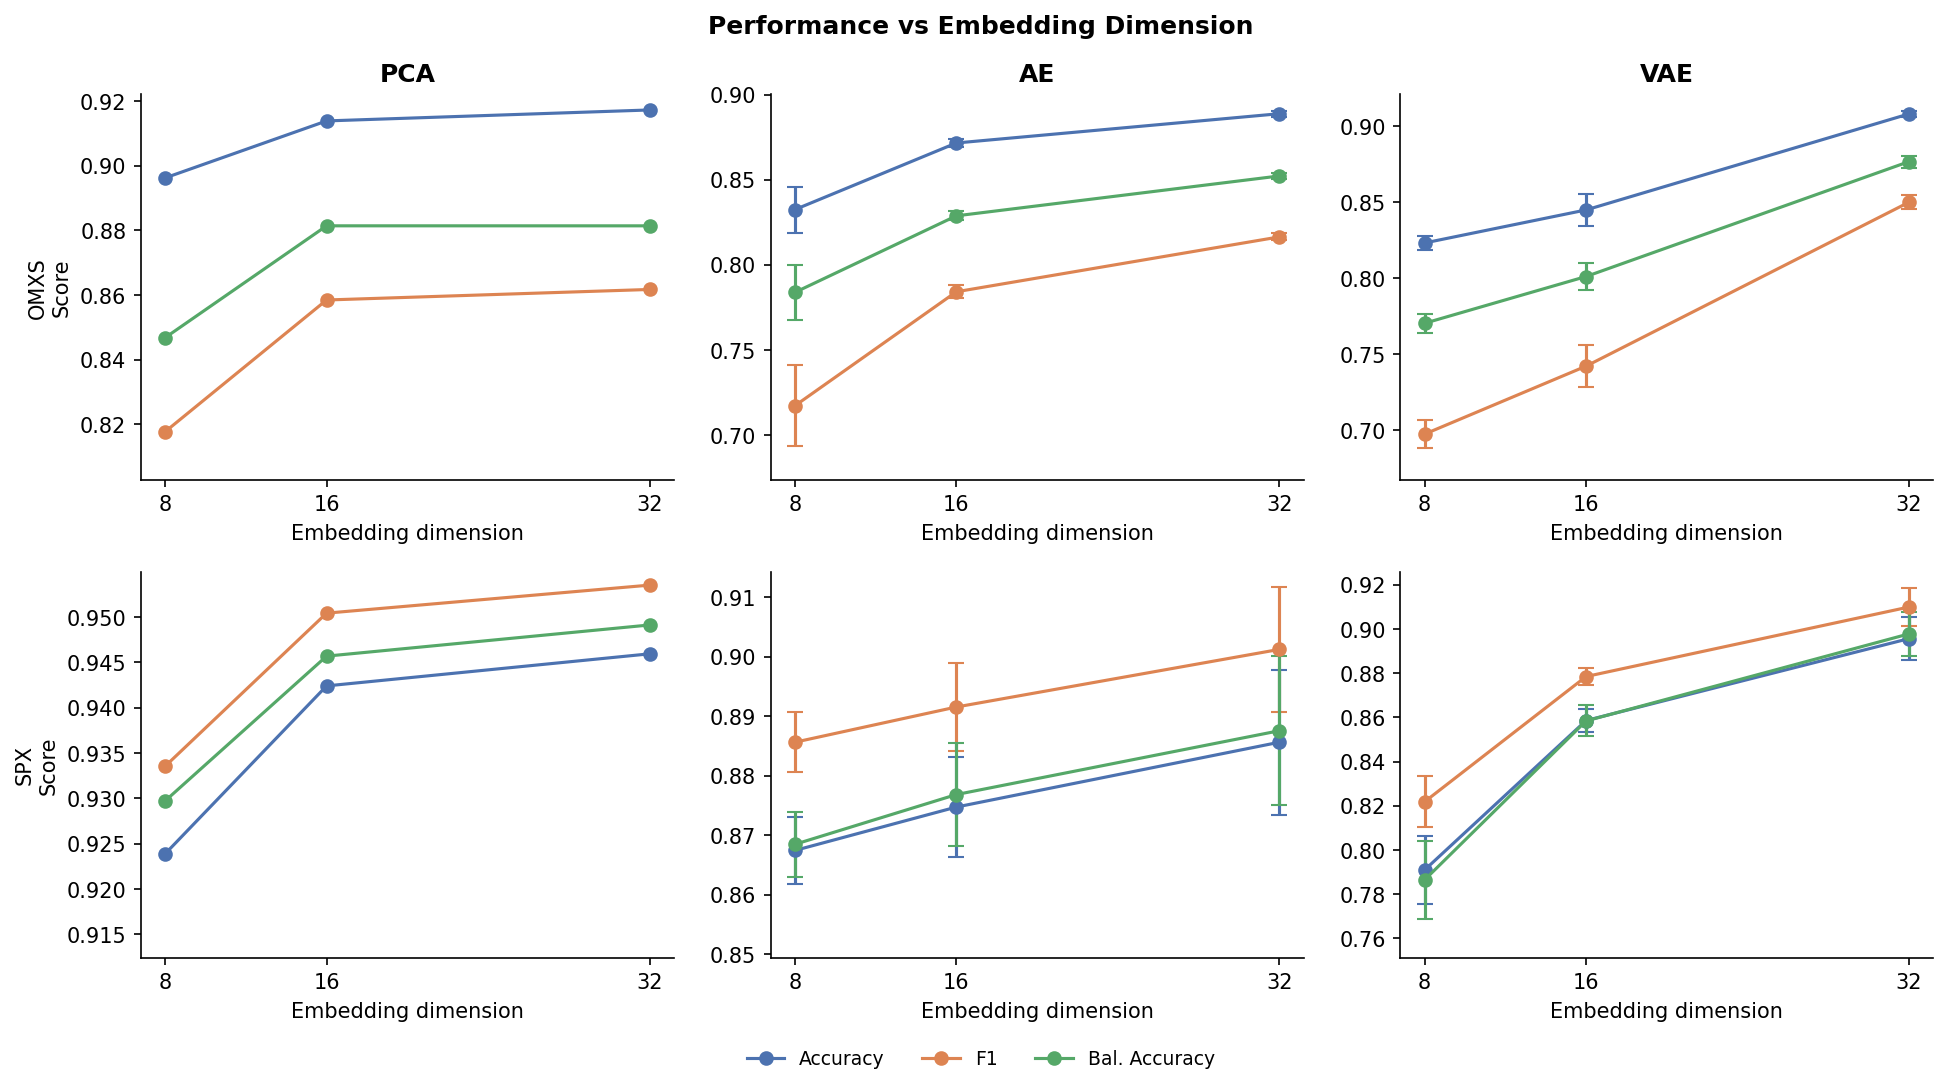

Saved dim_vs_perf.pdf / .png


In [9]:
METRIC_COLORS = {"test_accuracy": "#4C72B0", "test_f1": "#DD8452", "test_balanced_accuracy": "#55A868"}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for row_idx, market in enumerate(MARKETS):
    for col_idx, (method_name, src_df, is_agg) in enumerate([
        ("PCA",  df_pca,   False),
        ("AE",   ae_agg,   True),
        ("VAE",  vae_agg,  True),
    ]):
        ax = axes[row_idx][col_idx]
        sub = src_df[src_df["market"] == market].sort_values("embedding_dim")

        for metric in METRICS:
            label = METRIC_LABELS[metric]
            color = METRIC_COLORS[metric]
            if is_agg:
                ax.errorbar(
                    sub["embedding_dim"], sub[f"{metric}_mean"],
                    yerr=sub[f"{metric}_std"],
                    fmt="o-", label=label, color=color, capsize=4, linewidth=1.5,
                )
            else:
                ax.plot(
                    sub["embedding_dim"], sub[metric],
                    "o-", label=label, color=color, linewidth=1.5,
                )

        ax.set_xticks(DIMS)
        ax.set_xlabel("Embedding dimension")
        ax.set_ylim(bottom=max(0.0, ax.get_ylim()[0] - 0.01))

        if col_idx == 0:
            ax.set_ylabel(f"{market}\nScore")
        if row_idx == 0:
            ax.set_title(method_name, fontweight="bold")

fig.suptitle("Performance vs Embedding Dimension", fontweight="bold")

# Shared legend below the subplots
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "dim_vs_perf.pdf", bbox_inches="tight")
plt.savefig(PLOTS_DIR / "dim_vs_perf.png", bbox_inches="tight")
plt.show()
print("Saved dim_vs_perf.pdf / .png")

## 5. Cross-Market Comparison

In [10]:
cross_rows = []

for method_label, getter in [
    ("Baseline",       lambda mkt: {m: fmt(df_baseline[df_baseline["market"]==mkt].iloc[0][m]) for m in METRICS}),
    ("PCA (best dim)", lambda mkt: {m: fmt(best_pca(mkt)[m]) for m in METRICS}),
    ("AE (best dim)",  lambda mkt: {m: fmt(best_agg(ae_agg,  mkt)[f"{m}_mean"], best_agg(ae_agg,  mkt)[f"{m}_std"]) for m in METRICS}),
    ("VAE (best dim)", lambda mkt: {m: fmt(best_agg(vae_agg, mkt)[f"{m}_mean"], best_agg(vae_agg, mkt)[f"{m}_std"]) for m in METRICS}),
]:
    row = {"Method": method_label}
    for market in MARKETS:
        vals = getter(market)
        for m in METRICS:
            row[f"{market} {METRIC_LABELS[m]}"] = vals[m]
    cross_rows.append(row)

cross_df = pd.DataFrame(cross_rows)
display(cross_df)

,Method,OMXS Accuracy,OMXS F1,OMXS Bal. Accuracy,SPX Accuracy,SPX F1,SPX Bal. Accuracy
0,Baseline,0.8182,0.6876,0.7638,0.7979,0.8233,0.7994
1,PCA (best dim),0.9138,0.8584,0.8814,0.9459,0.9535,0.9491
2,AE (best dim),0.8887 ±0.0018,0.8164 ±0.0021,0.8522 ±0.0018,0.8856 ±0.0122,0.9012 ±0.0106,0.8876 ±0.0126
3,VAE (best dim),0.9080 ±0.0021,0.8500 ±0.0044,0.8766 ±0.0040,0.8956 ±0.0097,0.9099 ±0.0085,0.8978 ±0.0098


In [11]:
# LaTeX export — cross-market
latex_cross = cross_df.to_latex(
    index=False,
    escape=False,
    caption="Cross-market comparison of test-set performance (best embedding dimension per method).",
    label="tab:cross_market",
)
print(latex_cross)

(TABLES_DIR / "cross_market.tex").write_text(latex_cross)
cross_df.to_csv(TABLES_DIR / "cross_market.csv", index=False)
print("Saved cross_market.tex / .csv")

\begin{table}
\caption{Cross-market comparison of test-set performance (best embedding dimension per method).}
\label{tab:cross_market}
\begin{tabular}{lllllll}
\toprule
Method & OMXS Accuracy & OMXS F1 & OMXS Bal. Accuracy & SPX Accuracy & SPX F1 & SPX Bal. Accuracy \\
\midrule
Baseline & 0.8182 & 0.6876 & 0.7638 & 0.7979 & 0.8233 & 0.7994 \\
PCA (best dim) & 0.9138 & 0.8584 & 0.8814 & 0.9459 & 0.9535 & 0.9491 \\
AE (best dim) & 0.8887 ±0.0018 & 0.8164 ±0.0021 & 0.8522 ±0.0018 & 0.8856 ±0.0122 & 0.9012 ±0.0106 & 0.8876 ±0.0126 \\
VAE (best dim) & 0.9080 ±0.0021 & 0.8500 ±0.0044 & 0.8766 ±0.0040 & 0.8956 ±0.0097 & 0.9099 ±0.0085 & 0.8978 ±0.0098 \\
\bottomrule
\end{tabular}
\end{table}

Saved cross_market.tex / .csv
